# The `%%alice` magic command
The `%%alice` magic command allows to generate code and store it aw Jupyter Notebooks with ease.

It is recommended though to initialize the environment, e.g. to define folders where Alice should have access to and what LLM-server to use.

In [1]:
from sand_bob import initialize, config_scadsai_llm

# e.g. select our institutional server:
config_scadsai_llm()

# give read-acces to a folder
initialize(input_host_path="input_data/", n_codefix_attempts=2, n_feedback_iterations=1) 

Task,Function,Model
Generate code,prompt_scadsai_llm,openai/gpt-oss-120b
Fix code,prompt_scadsai_llm,openai/gpt-oss-120b
Determine dependencies,prompt_scadsai_llm,openai/gpt-oss-120b
Generate code feedback,prompt_scadsai_llm,google/gemma-4-31B-it
Summarize code,prompt_scadsai_llm,openai/gpt-oss-120b
Notebook conversion,prompt_scadsai_llm,openai/gpt-oss-120b
Task,Function,Model
Generate code,prompt_scadsai_llm,openai/gpt-oss-120b
Fix code,prompt_scadsai_llm,openai/gpt-oss-120b
Determine dependencies,prompt_scadsai_llm,openai/gpt-oss-120b

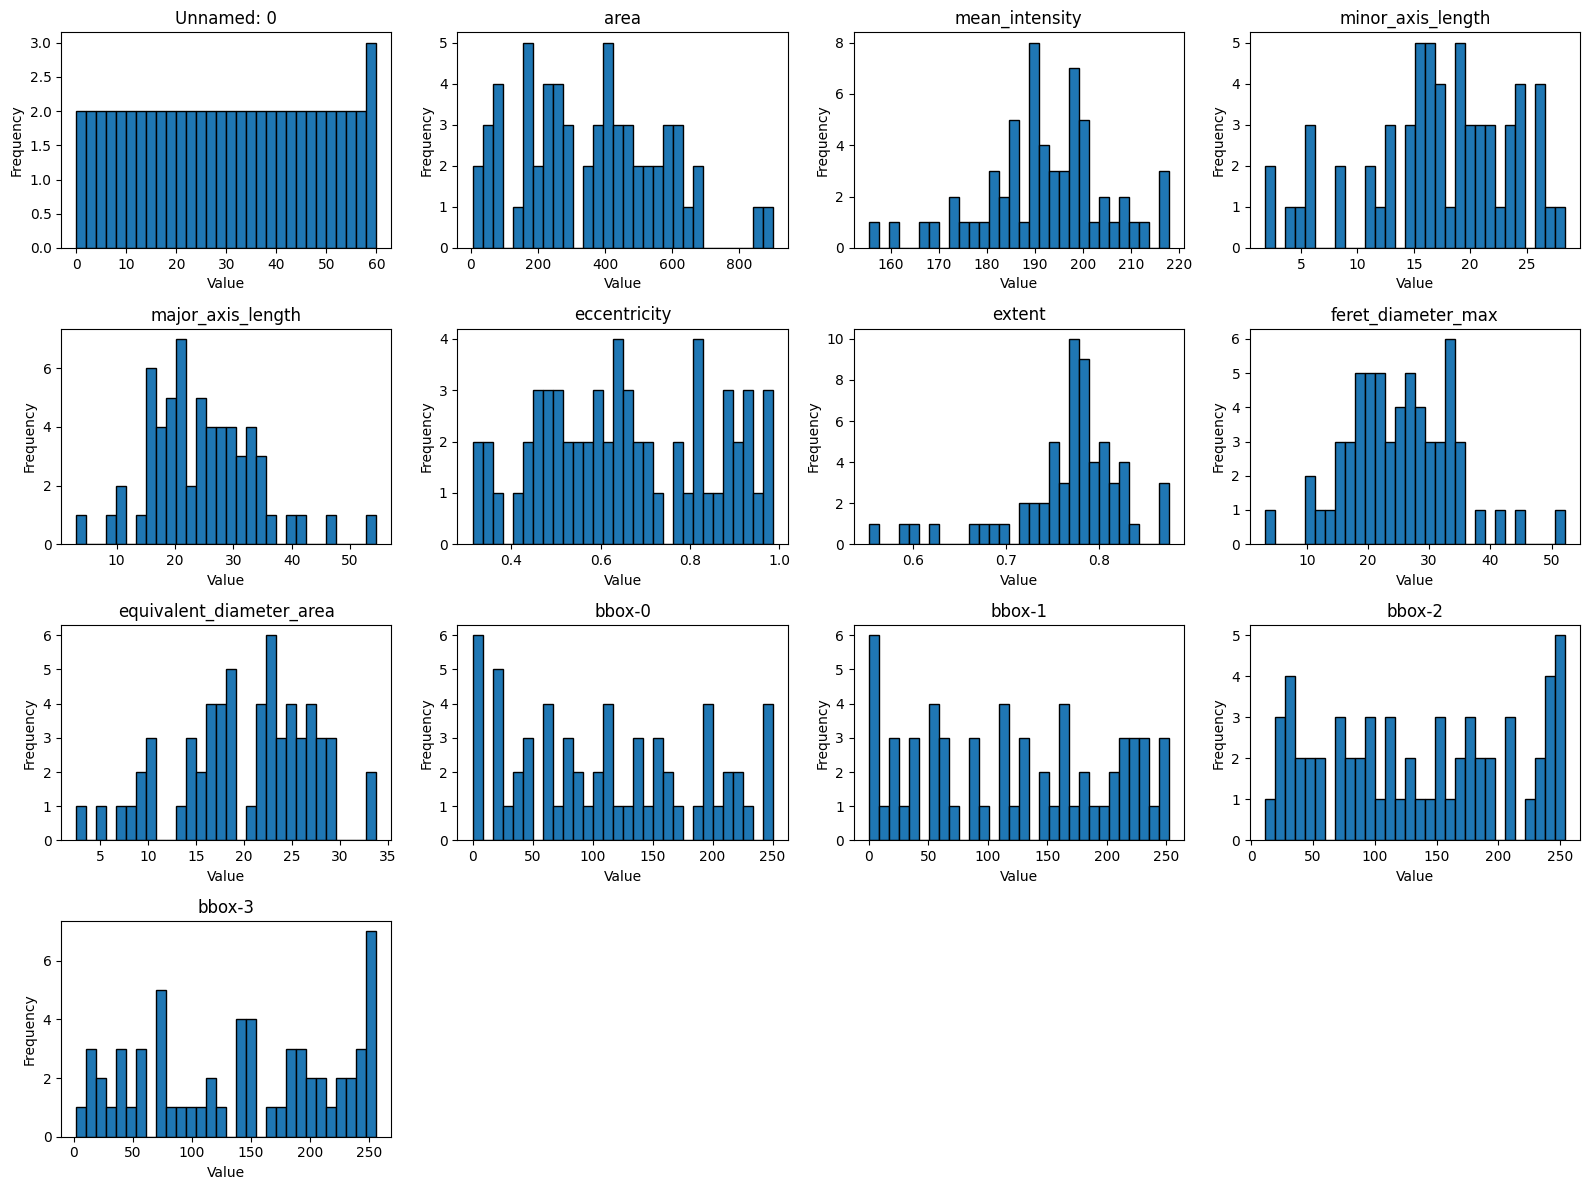
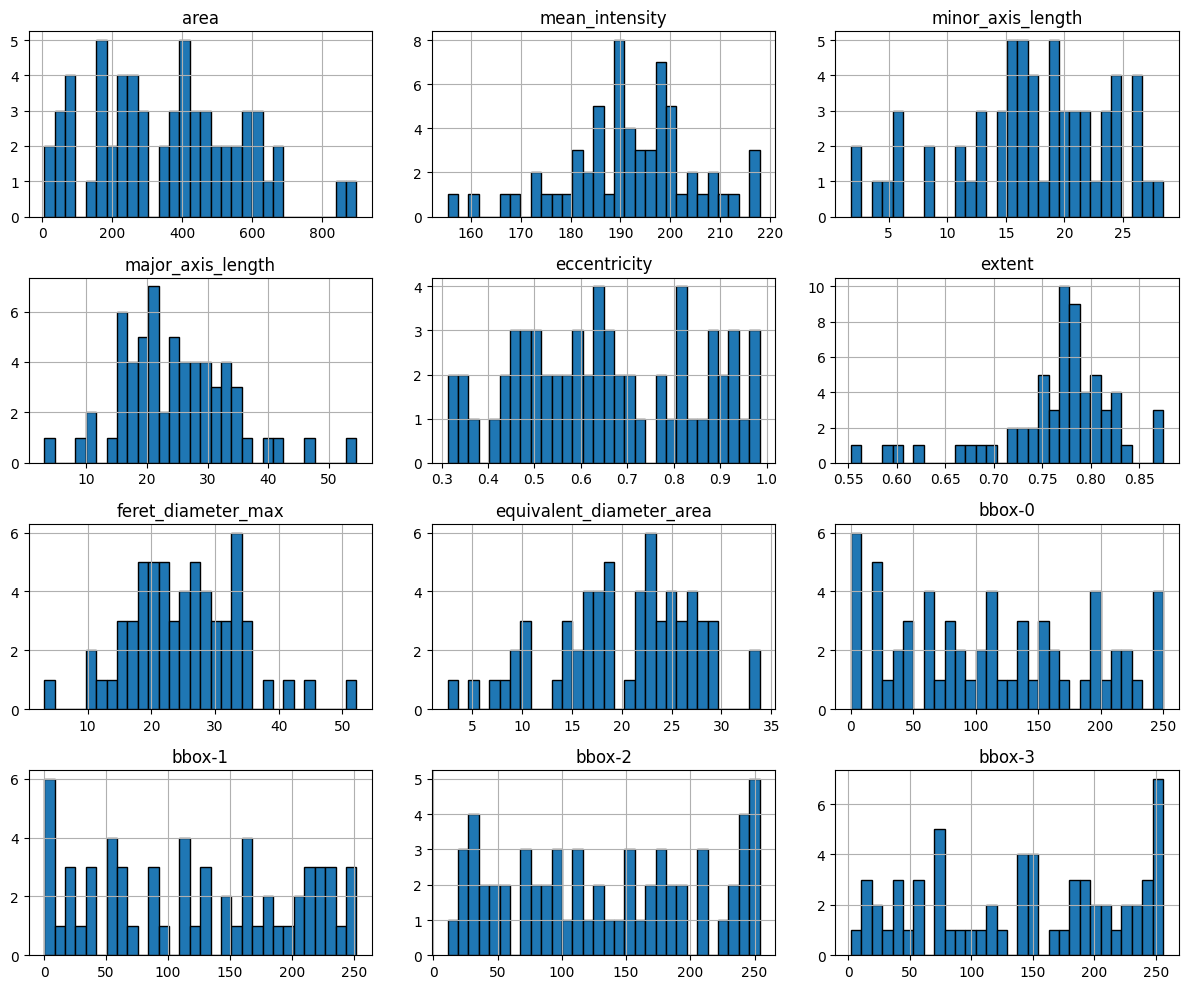

Output()

ExecutionResult(stdout='[jupytext] Reading notebook.mystnb in format mystnb\n[jupytext] Writing notebook.ipynb\n[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 106279 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=6.654916524887085, run_time=6.558557987213135, build_time=0.0, container_id='64bfe0d1c83b0d11f011ee85c9eee4f9faa97e04e3fd1688e3be3b6f111a139c', prompt='\nYou are an expert in python programming. You have a list of framework constraints which you MUST follow.\nYour task is to generate a fully functional code snippet that will be used to fulfill the prompt.\nAssume your code will be executed in a Jupyter notebook cell.\n\n# Framework constraints\n* You may use the following libraries, but only if necessary: scikit-image, numpy, pandas, matplotlib, seaborn, tqdm, scipy\n* When saving files, use the following folder: "/display_output/". Do not create this folder. It exists already.\n* pip install is STRICTLY PROHIBITED. You can only use the libraries mentioned above.\n* Statistics: When applying statisticals test, ENSURE that pre-conditions for the tests are checked before the tests are performed.\n* Final result output (print or display calls): \n  * The second-last print or display call should be a description of the result (e.g. the measurment and a physical unit if relevant).\n  * The last print or display call should be the final result ONLY.\n  * If the task is to generate a count, ratio or measurements, print the final result using a separate `print` call. \n  * If the task is to answer a yes/no question, print "Yes" or "No" using a separate `print` call. Do not create any JSON for this.\n  * If the task is to generate a plot, display the plot.\n  * Also plot intermediate results if possible.\n* Final result output (file writing):\n  * If the task is to generate a text or a string, write the text or string to "/display_output/final_result.txt".\n  * If the task is to generate a table, write the table to "/display_output/final_result.csv".\n  * If the final result is a plot, display this plot and afterwards, save it in the folder /display_output as .png and as .svg file and print the filename of the .png in the final output of the program.\n  * If the task is to generate a number, list, array or dictionary, write the result to "/display_output/final_result.json".\n    In that case, do not add additional data structures. Simply json.dump the result to the file. E.g. if the result is x=2, then just do `json.dump(x, fp)`.\n  * If the final result was saved as file, make sure to print the filename in the final output of the program.  \n* Keep the code short and concise.\n\n\n\nGiven some task, code to fulfill the task, and detailed feedback, propose new code that incorporates the feedback.\nMake sure to keep the code format.\n\n# Task\n                \nPlot histograms of all columns in input_data/measurements.csv\n\n                \n# Code\n\n```\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport math\nimport os\n\n# Load the data\ncsv_path = "input_data/measurements.csv"\ndf = pd.read_csv(csv_path)\n\n# Determine layout for sub‑plots\nn_cols = df.shape[1]\nn_rows = math.ceil(math.sqrt(n_cols))\nn_cols_plot = math.ceil(n_cols / n_rows)\n\nfig, axes = plt.subplots(n_rows, n_cols_plot, figsize=(4 * n_cols_plot, 3 * n_rows))\naxes = axes.flatten()  # simplify indexing\n\n# Plot a histogram for each column\nfor i, col in enumerate(df.columns):\n    ax = axes[i]\n    ax.hist(df[col].dropna(), bins=30, edgecolor=\'black\')\n    ax.set_title(col)\n    ax.set_xlabel(\'Value\')\n    ax.set_ylabel(\'Frequency\')\n\n# Hide any unused sub‑plots\nfor j in range(i + 1, len(axes)):\n    axes[j].axis(\'off\')\n\nplt.tight_layout()\n\n# Save the figure\npng_path = "/display_output/histograms.png"\nsvg_path = "/display_output/histograms.svg"\nfig.savefig(png_path, dpi=300, bbox_inches=\'tight\')\nfig.savefig(svg_path, format=\'svg\', bbox_inc

In [2]:
%%alice
Plot histograms of all columns in input_data/measurements.csv

## Requesting multiple code samples

You can also request Alice to compute multiple results, be generating `n` independent code samples. This can be done `p` times in parallel and `i` times iteratively; resulting in `n = p * i` results.

In [3]:
initialize(input_host_path="input_data/", n_parallel=5, n_iterative=2)


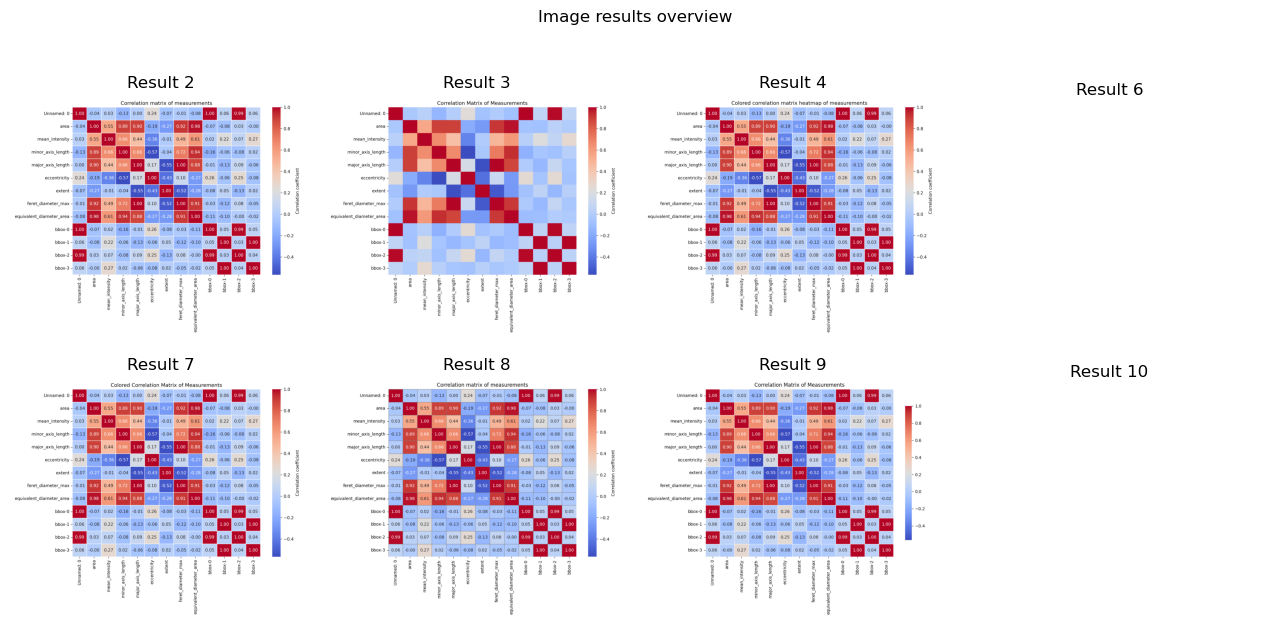
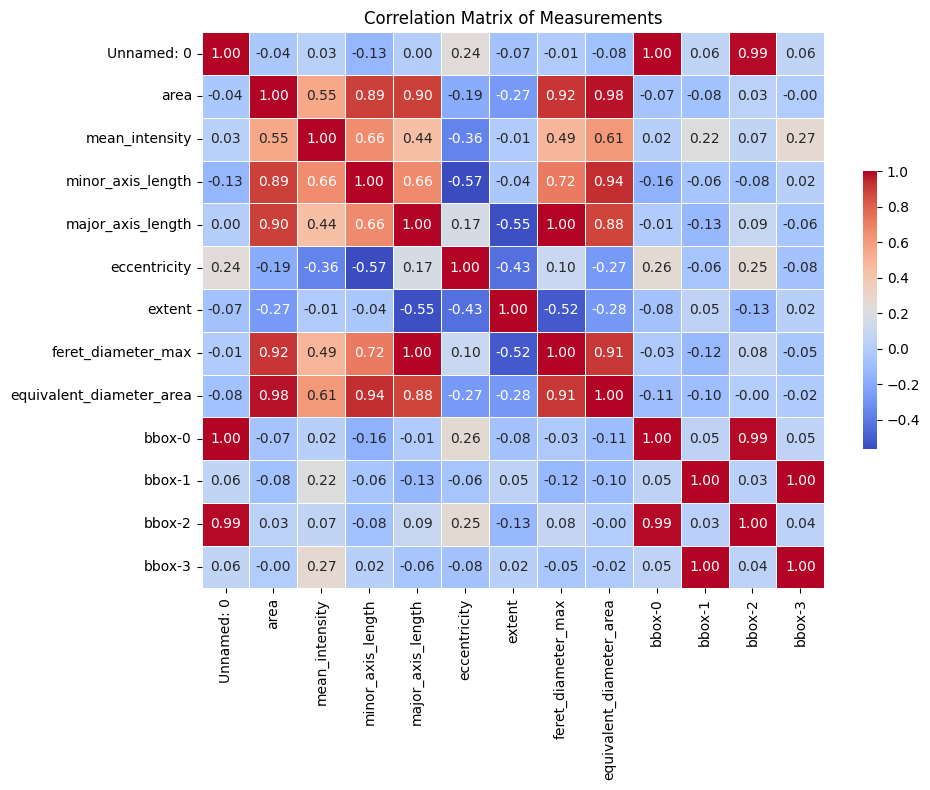
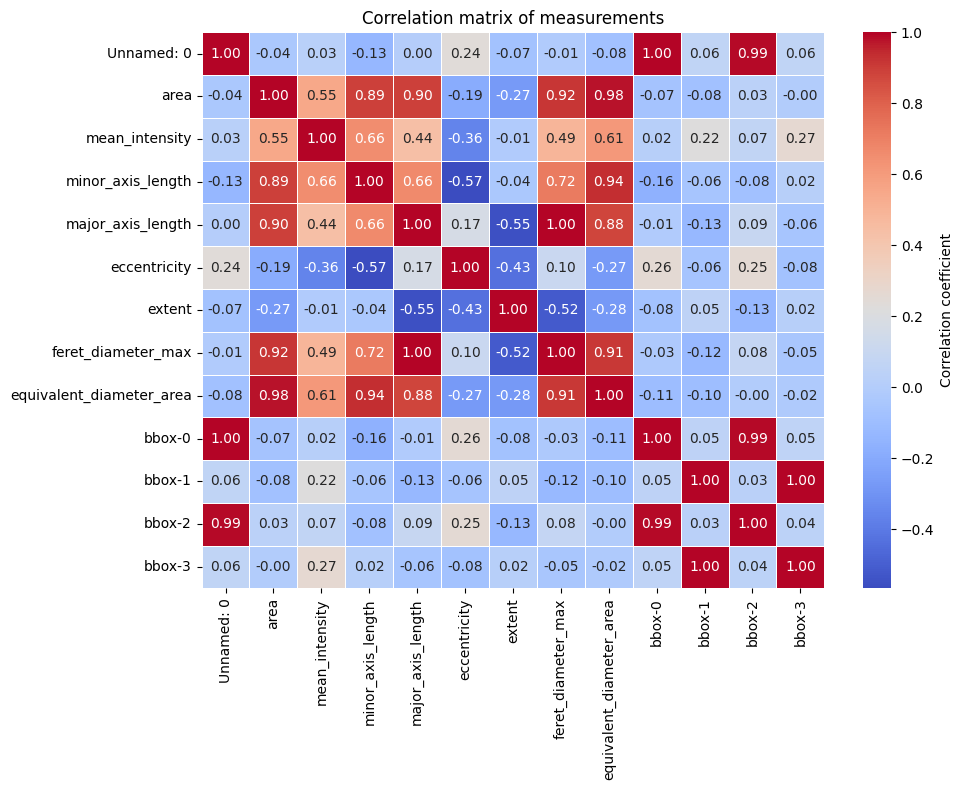
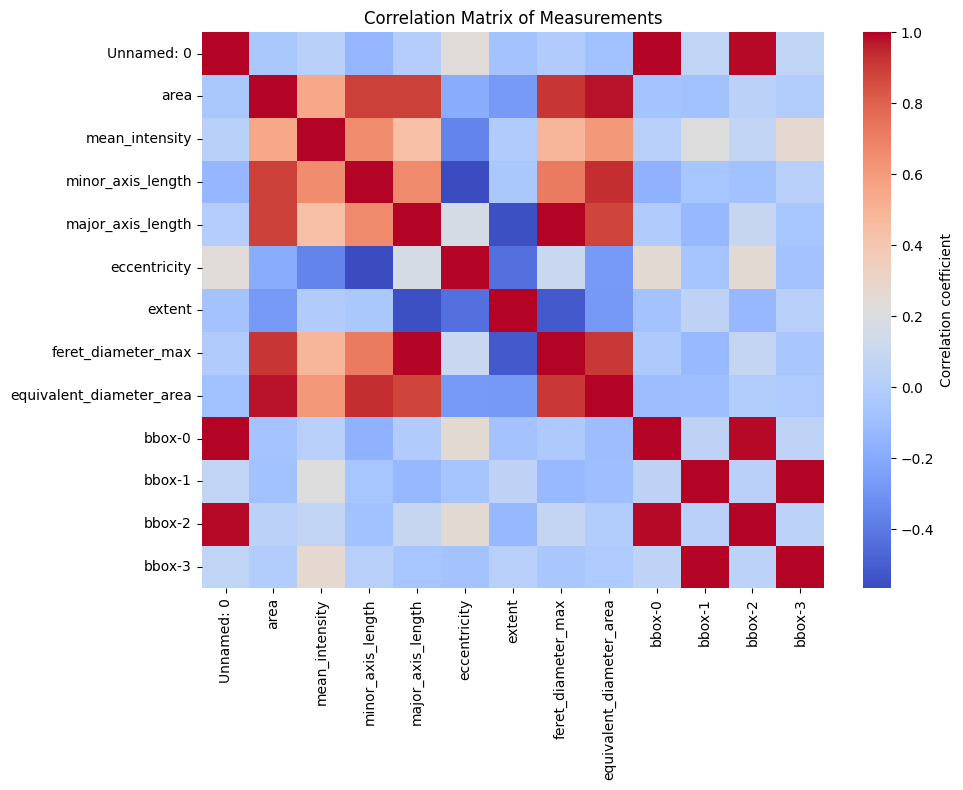
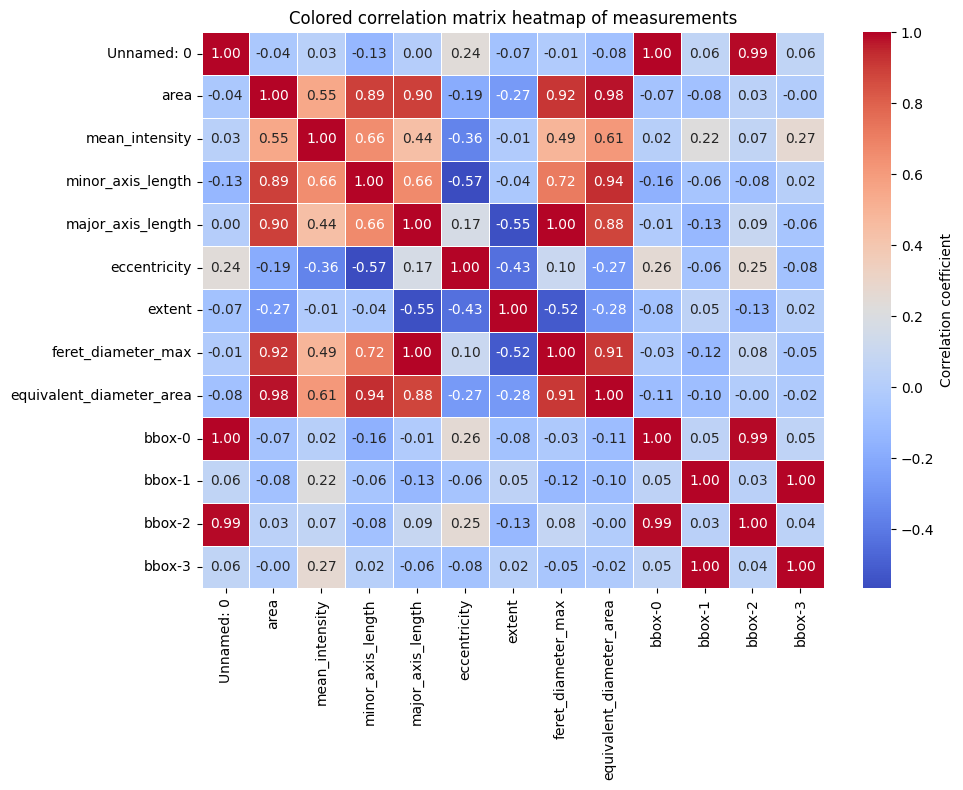
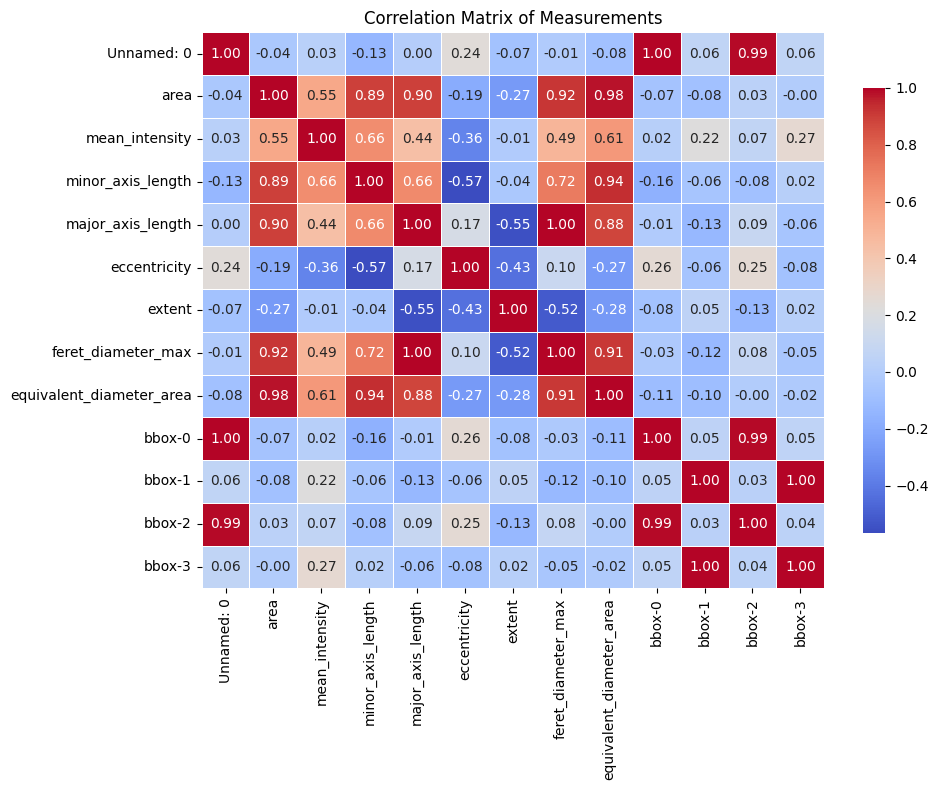
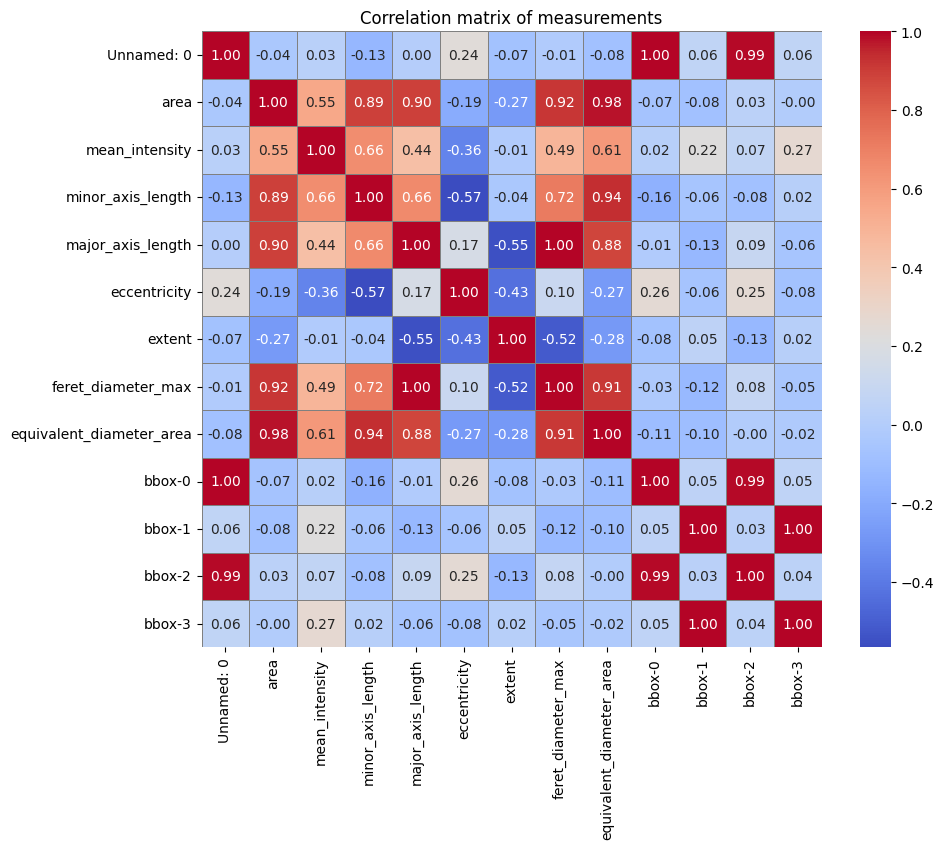
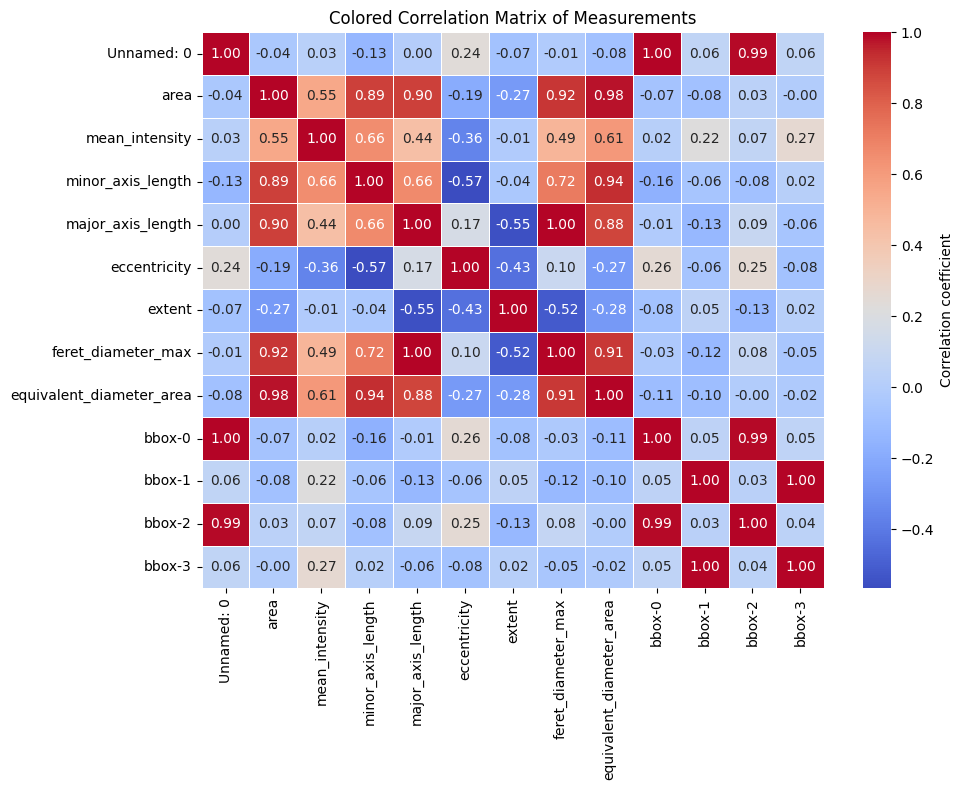
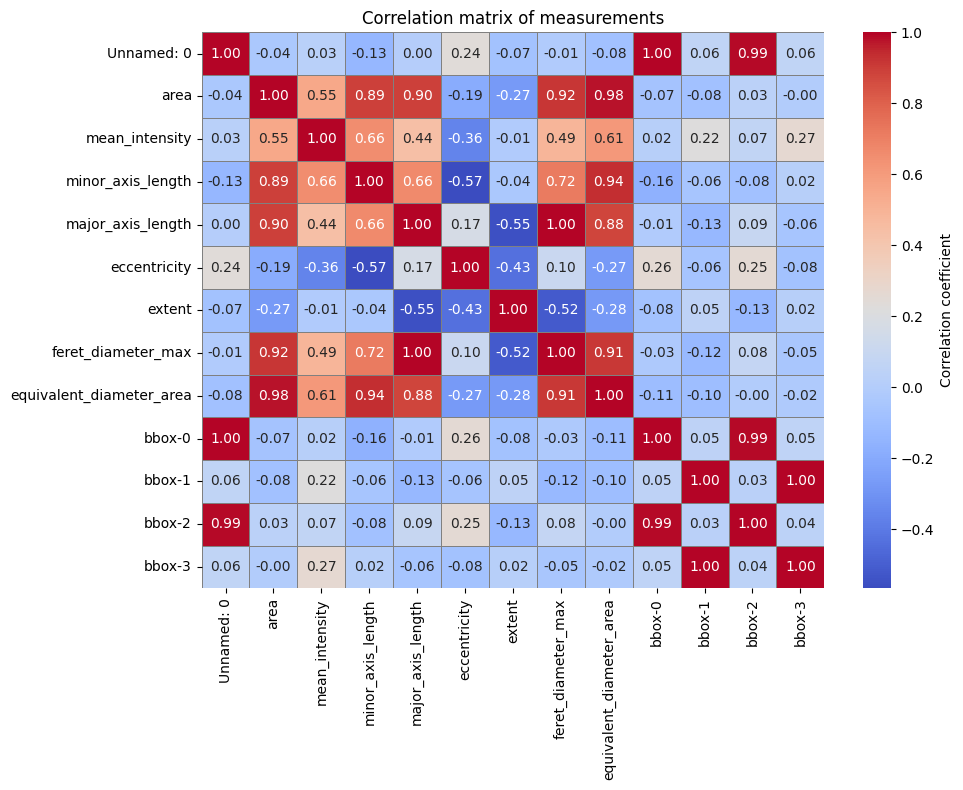
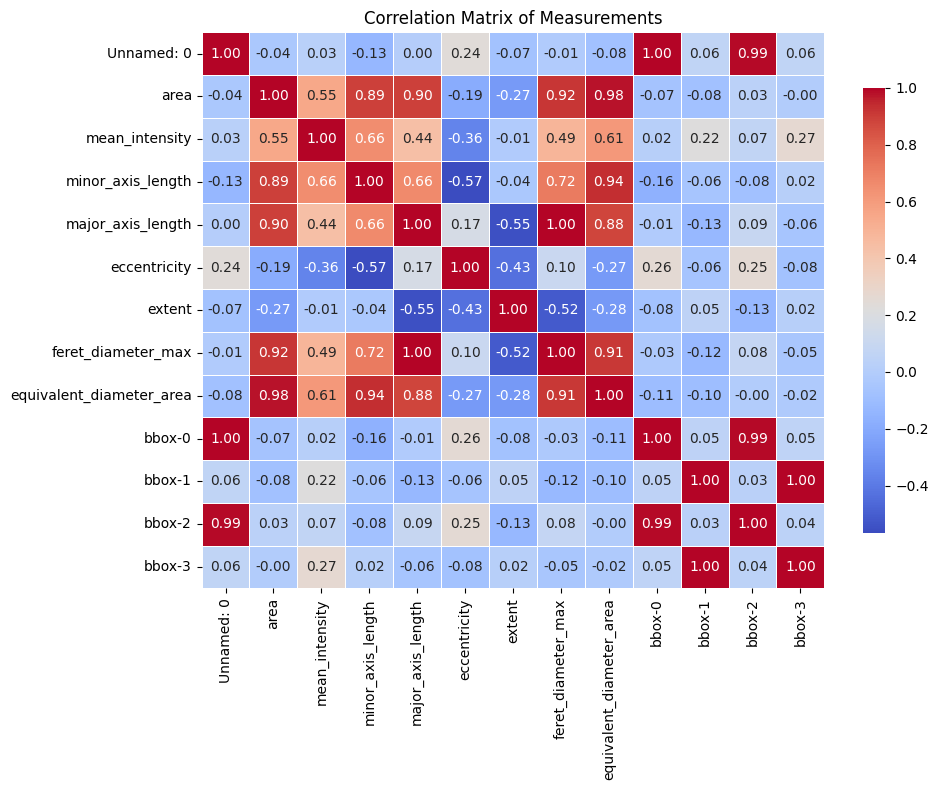
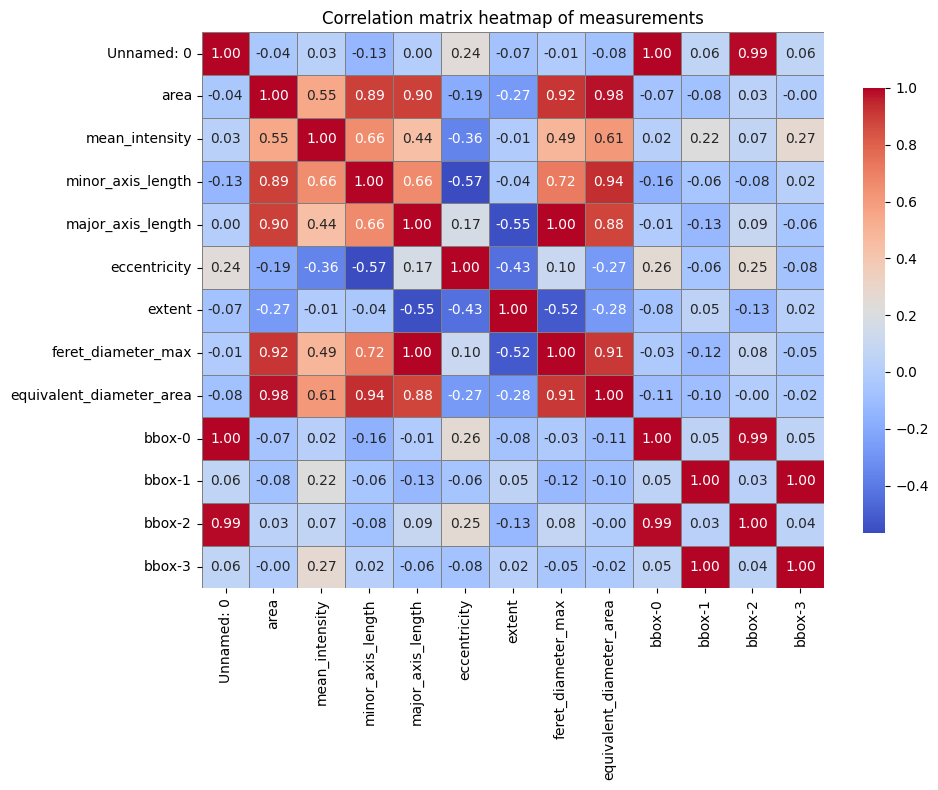

Output()

In [4]:
%%alice
Visualize a coloured correlation matrix of all columns in "input_data/measurements.csv"

## Accessing results

You can also continue processing results afterwards, by accessing the global `alice_result` variable. In case you asked for a single result, this variable will contain it. If you asked for muliple results, the variable will contain a list.


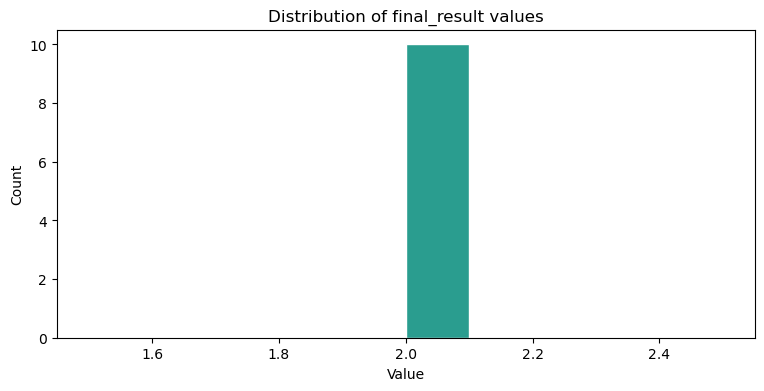

Output()

In [5]:
%%alice
how many b are in blueberry?

The result of Alice's actions are stored in the `alice_result` variable.

In [6]:
[r.final_result for r in alice_result]

[2, 2, 2, 2, 2, 2.0, 2, 2, 2, 2]